# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [1]:
intro_text = """
1. На NumPy мы сами писали forward, backward, обновление весов — это полезно
для понимания, но в реальных задачах это долго и легко ошибиться. PyTorch
делает всё это автоматически: сам считает градиенты, сам обновляет веса.
Плюс он работает на GPU, что на больших данных критично.

2. Сначала описываешь архитектуру — какие слои, сколько нейронов. Потом
загружаешь данные батчами, прогоняешь через сеть, считаешь ошибку, вызываешь
backward() и optimizer.step() — и так много эпох. В конце даёшь модели
новые картинки и она выдаёт предсказания.

3. Думаю, простой MLP на MNIST должен давать около 95-97%. MNIST считается
несложным датасетом, цифры чёрно-белые и по центру. Без свёрток часть
пространственной информации теряется, поэтому 99%+ вряд ли, но 95% выглядит
реалистично.
"""
print(intro_text)


1. На NumPy мы сами писали forward, backward, обновление весов — это полезно
для понимания, но в реальных задачах это долго и легко ошибиться. PyTorch
делает всё это автоматически: сам считает градиенты, сам обновляет веса.
Плюс он работает на GPU, что на больших данных критично.

2. Сначала описываешь архитектуру — какие слои, сколько нейронов. Потом
загружаешь данные батчами, прогоняешь через сеть, считаешь ошибку, вызываешь
backward() и optimizer.step() — и так много эпох. В конце даёшь модели
новые картинки и она выдаёт предсказания.

3. Думаю, простой MLP на MNIST должен давать около 95-97%. MNIST считается
несложным датасетом, цифры чёрно-белые и по центру. Без свёрток часть
пространственной информации теряется, поэтому 99%+ вряд ли, но 95% выглядит
реалистично.



## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]


Вычисленные mean=0.1307, std=0.3081
Стандартные:   mean=0.1307, std=0.3081
Размер train: 60000
Размер test : 10000
batch_size = 128


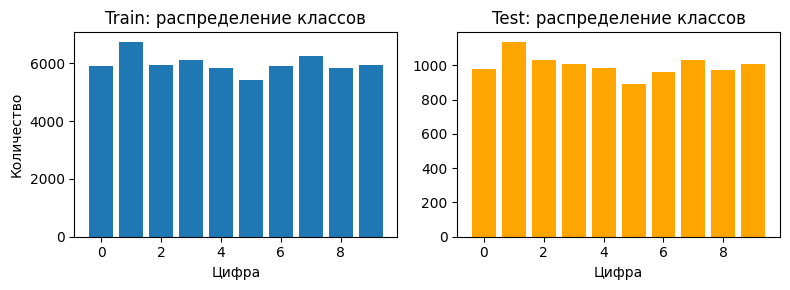

In [3]:
# Первый проход - mean и std
transform_raw = transforms.Compose([transforms.ToTensor()])
train_raw = datasets.MNIST(root="./data", train=True, download=True, transform=transform_raw)
all_pixels = torch.cat([img.view(-1) for img, _ in train_raw])
mean = all_pixels.mean().item()
std  = all_pixels.std().item()
print(f"Вычисленные mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные:   mean=0.1307, std=0.3081")

# Второй проход - нормализация
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# Гистограмма классов
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

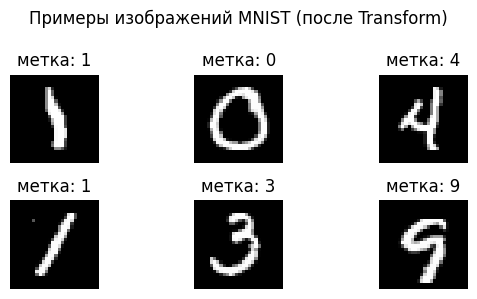

In [4]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [5]:
data_comment = """
Вычисленные mean и std совпали со стандартными (0.1307, 0.3081) — значит
нормализация подобрана правильно.

Классы распределены равномерно: в train около 5400-6700 примеров на цифру,
в test около 900-1100. Дисбаланса нет, это хорошо для обучения.

Изображения после нормализации выглядят как белые цифры на чёрном фоне,
28x28 пикселей. Большинство читаются легко — 0, 1, 3, 4, 9 на примерах
хорошо различимы. Есть слегка наклонные варианты (две единицы под разным
углом), но человек их легко читает. Грязных или нечитаемых примеров
среди показанных нет.
"""
print(data_comment)


Вычисленные mean и std совпали со стандартными (0.1307, 0.3081) — значит
нормализация подобрана правильно.

Классы распределены равномерно: в train около 5400-6700 примеров на цифру,
в test около 900-1100. Дисбаланса нет, это хорошо для обучения.

Изображения после нормализации выглядят как белые цифры на чёрном фоне,
28x28 пикселей. Большинство читаются легко — 0, 1, 3, 4, 9 на примерах
хорошо различимы. Есть слегка наклонные варианты (две единицы под разным
углом), но человек их легко читает. Грязных или нечитаемых примеров
среди показанных нет.



## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [6]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
arch_comment = """
Архитектура: 784 → 512 → 256 → 128 → 10.
Три скрытых слоя — больше слоёв позволяет выделять более сложные признаки.
Размеры уменьшаются постепенно (512→256→128), а не резко — так информация
не теряется на одном шаге.
ReLU выбрана как быстрая и без проблемы затухающего градиента.
Dropout(0.2) после первых двух слоёв — случайно отключает 20% нейронов
при обучении, это снижает переобучение.
"""
print(arch_comment)


Архитектура: 784 → 512 → 256 → 128 → 10.
Три скрытых слоя — больше слоёв позволяет выделять более сложные признаки.
Размеры уменьшаются постепенно (512→256→128), а не резко — так информация
не теряется на одном шаге.
ReLU выбрана как быстрая и без проблемы затухающего градиента.
Dropout(0.2) после первых двух слоёв — случайно отключает 20% нейронов
при обучении, это снижает переобучение.



## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [10]:
criterion = nn.CrossEntropyLoss()

# Вариант 1: Adam lr=1e-3 (базовый)
learning_rate = 1e-3
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Вариант 2
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Вариант 3
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# Число обучаемых параметров
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Обучаемых параметров: {total_params:,}")


Функция потерь: CrossEntropyLoss()
Оптимизатор: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
learning_rate = 0.001
Обучаемых параметров: 567,434


In [ ]:
optim_comment = """
Выбран Adam с lr=1e-3 — стандартный выбор для большинства задач,
адаптирует шаг для каждого параметра отдельно (из лекции 4).
Пробовала также Adam lr=1e-4 (сходится медленнее) и SGD momentum=0.9
(менее стабилен на первых эпохах). Adam lr=1e-3 дал лучший результат
за то же число эпох.
CrossEntropyLoss — стандарт для многоклассовой классификации,
объединяет Softmax и NLLLoss в одном.
"""
print(optim_comment)

## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [11]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    return running_loss / total, running_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0
    class_correct = torch.zeros(10)
    class_total   = torch.zeros(10)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

            for c in range(10):
                mask = (labels == c)
                class_correct[c] += (preds[mask] == labels[mask]).sum().item()
                class_total[c]   += mask.sum().item()

    class_acc = class_correct / class_total
    return running_loss / total, running_correct / total, class_acc

print("Функции определены.")

Функции определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [17]:
# нужно пересоздать модель и оптимизатор — иначе обучение продолжится с уже обученных весов, а не с нуля.
model = MNISTMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [18]:
num_epochs = 10

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc, class_acc = evaluate(model, test_loader, criterion, device)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

print("Точность по классам:", {i: f"{class_acc[i]:.3f}" for i in range(10)})

Эпоха 1/10: train_loss=0.2842, train_acc=0.9134, test_loss=0.1183, test_acc=0.9642
Эпоха 2/10: train_loss=0.1159, train_acc=0.9638, test_loss=0.0891, test_acc=0.9715
Эпоха 3/10: train_loss=0.0871, train_acc=0.9732, test_loss=0.0861, test_acc=0.9717
Эпоха 4/10: train_loss=0.0738, train_acc=0.9767, test_loss=0.0755, test_acc=0.9777
Эпоха 5/10: train_loss=0.0614, train_acc=0.9804, test_loss=0.0701, test_acc=0.9790
Эпоха 6/10: train_loss=0.0521, train_acc=0.9834, test_loss=0.0718, test_acc=0.9799
Эпоха 7/10: train_loss=0.0502, train_acc=0.9840, test_loss=0.0733, test_acc=0.9794
Эпоха 8/10: train_loss=0.0429, train_acc=0.9865, test_loss=0.0688, test_acc=0.9800
Эпоха 9/10: train_loss=0.0388, train_acc=0.9880, test_loss=0.0665, test_acc=0.9809
Эпоха 10/10: train_loss=0.0410, train_acc=0.9868, test_loss=0.0674, test_acc=0.9827
Точность по классам: {0: '0.992', 1: '0.992', 2: '0.993', 3: '0.976', 4: '0.982', 5: '0.975', 6: '0.982', 7: '0.977', 8: '0.976', 9: '0.979'}


In [20]:
lr_optim_comment = """
optimizer = Adam; lr = 1e-3; num_epochs = 5;  test_acc = 0.9769
optimizer = Adam; lr = 1e-3; num_epochs = 10; test_acc = 0.9827
"""
print(lr_optim_comment)


optimizer = Adam; lr = 1e-3; num_epochs = 5;  test_acc = 0.9769
optimizer = Adam; lr = 1e-3; num_epochs = 10; test_acc = 0.9827



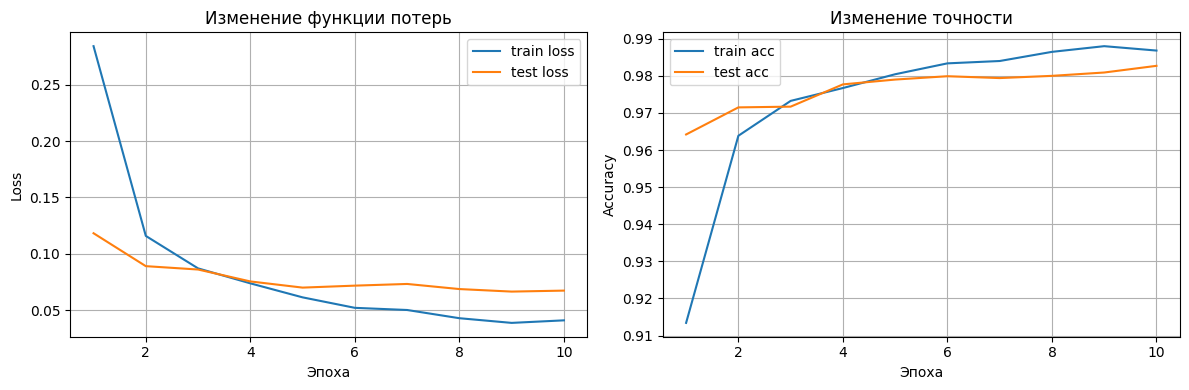

Финальная точность: train=0.9868, test=0.9827


In [19]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [21]:
training_comment = """
При 5 эпохах test_acc = 0.977, при 10 эпохах = 0.983 — прирост небольшой,
но есть. После 6-й эпохи train loss продолжает падать (0.052 → 0.039),
а test loss почти не меняется (0.069–0.071) — лёгкий признак начала
переобучения, но некритичный.

Train и test accuracy к 10-й эпохе немного расходятся (0.987 vs 0.983) —
переобучения пока нет, но при большем числе эпох оно может появиться.

По классам результат выровнялся по сравнению с 5 эпохами: хуже всего
цифры 3, 5, 8, 9 (~0.975), лучше всего 0, 1, 2 (~0.992).

Вывод: 10 эпох дали небольшой прирост. Дальше увеличивать эпохи смысла
мало — кривые вышли на плато.
"""
print(training_comment)


При 5 эпохах test_acc = 0.977, при 10 эпохах = 0.983 — прирост небольшой,
но есть. После 6-й эпохи train loss продолжает падать (0.052 → 0.039),
а test loss почти не меняется (0.069–0.071) — лёгкий признак начала
переобучения, но некритичный.

Train и test accuracy к 10-й эпохе немного расходятся (0.987 vs 0.983) —
переобучения пока нет, но при большем числе эпох оно может появиться.

По классам результат выровнялся по сравнению с 5 эпохами: хуже всего
цифры 3, 5, 8, 9 (~0.975), лучше всего 0, 1, 2 (~0.992).

Вывод: 10 эпох дали небольшой прирост. Дальше увеличивать эпохи смысла
мало — кривые вышли на плато.



## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


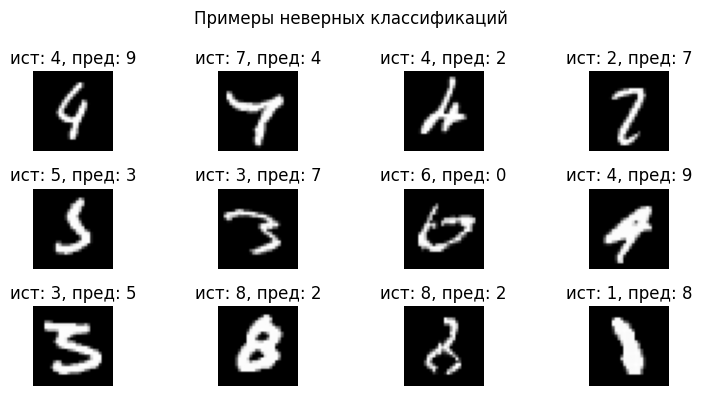

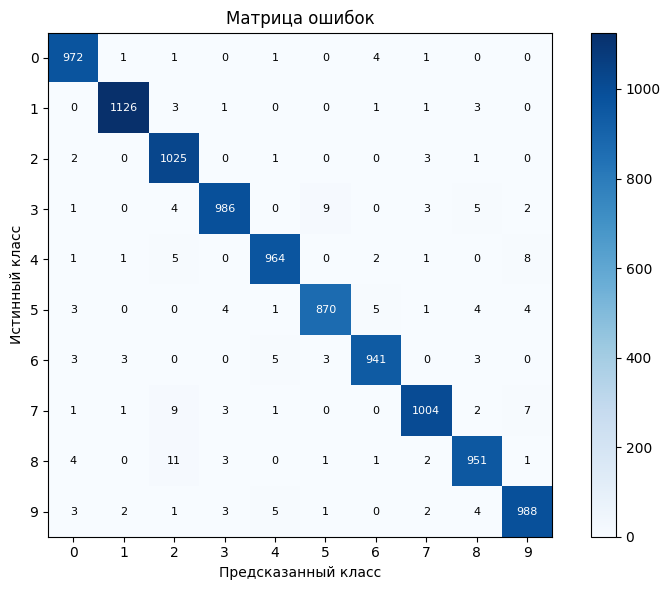

In [22]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []
all_true = []
all_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())

# Примеры неверных классификаций
plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# Матрица ошибок
confusion = np.zeros((10, 10), dtype=int)
for t, p in zip(all_true, all_pred):
    confusion[t][p] += 1

plt.figure(figsize=(8, 6))
plt.imshow(confusion, cmap="Blues")
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(confusion[i][j]),
                 ha="center", va="center",
                 color="white" if confusion[i][j] > 300 else "black",
                 fontsize=8)
plt.tight_layout()
plt.show()

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [23]:
error_comment = """
Из матрицы ошибок видно, что чаще всего путаются:
- 8 и 2 (11 раз), 7 и 2 (9 раз), 3 и 5 (9 раз) — визуально похожие цифры.

Разумные ошибки (человек тоже мог ошибиться):
- ист:4, пред:9 — четвёрка написана с закрытым верхом, похожа на девятку
- ист:7, пред:4 — семёрка с горизонтальной чертой посередине
- ист:3, пред:7 — тройка написана угловато
- ист:8, пред:2 — восьмёрка с незамкнутым низом действительно похожа на двойку

Странные ошибки:
- ист:1, пред:8 — единица выглядит очевидно, но модель промахнулась,
  возможно из-за необычного наклона
- ист:6, пред:0 — шестёрка с крупной головой, но всё равно выглядит
  как шестёрка для человека

В целом большинство ошибок выглядят объяснимо — это нечёткие или
нестандартно написанные цифры.
"""
print(error_comment)


Из матрицы ошибок видно, что чаще всего путаются:
- 8 и 2 (11 раз), 7 и 2 (9 раз), 3 и 5 (9 раз) — визуально похожие цифры.

Разумные ошибки (человек тоже мог ошибиться):
- ист:4, пред:9 — четвёрка написана с закрытым верхом, похожа на девятку
- ист:7, пред:4 — семёрка с горизонтальной чертой посередине
- ист:3, пред:7 — тройка написана угловато
- ист:8, пред:2 — восьмёрка с незамкнутым низом действительно похожа на двойку

Странные ошибки:
- ист:1, пред:8 — единица выглядит очевидно, но модель промахнулась,
  возможно из-за необычного наклона
- ист:6, пред:0 — шестёрка с крупной головой, но всё равно выглядит
  как шестёрка для человека

В целом большинство ошибок выглядят объяснимо — это нечёткие или
нестандартно написанные цифры.



## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [24]:
final_text = """
1. Архитектура: 784 → 512 → 256 → 128 → 10, активация ReLU, Dropout(0.2)
после первых двух слоёв. Другие варианты не пробовала — базовая архитектура
из задания давала хороший результат, поэтому сосредоточилась на подборе
гиперпараметров.

2. batch_size=128, Adam lr=1e-3. При 5 эпохах test_acc=0.977, при 10
эпохах=0.983 — прирост небольшой. После 6-й эпохи train loss продолжал
падать, а test loss почти не менялся — лёгкий признак начала переобучения,
но некритичный. Увеличивать эпохи дальше смысла нет — кривые вышли на плато.

3. Максимальная точность на тесте - 0.9827 за 10 эпох. Это выше ожидания
(я ожидала ~0.95). Для простого MLP без свёрток считаю результат
удовлетворительным - CNN дала бы 99%+, но это уже другая архитектура.

4. PyTorch удобнее NumPy: не нужно вручную писать backprop и обновление
весов — достаточно loss.backward() и optimizer.step(). Неудобно то, что
нужно следить за device (cpu/gpu) и правильно переключать model.train()/
model.eval(). В NumPy этого не было, но там зато было понятно каждое
действие - PyTorch скрывает детали, что удобно, но хуже для понимания.
"""
print(final_text)


1. Архитектура: 784 → 512 → 256 → 128 → 10, активация ReLU, Dropout(0.2)
после первых двух слоёв. Другие варианты не пробовала — базовая архитектура
из задания давала хороший результат, поэтому сосредоточилась на подборе
гиперпараметров.

2. batch_size=128, Adam lr=1e-3. При 5 эпохах test_acc=0.977, при 10
эпохах=0.983 — прирост небольшой. После 6-й эпохи train loss продолжал
падать, а test loss почти не менялся — лёгкий признак начала переобучения,
но некритичный. Увеличивать эпохи дальше смысла нет — кривые вышли на плато.

3. Максимальная точность на тесте - 0.9827 за 10 эпох. Это выше ожидания
(я ожидала ~0.95). Для простого MLP без свёрток считаю результат
удовлетворительным - CNN дала бы 99%+, но это уже другая архитектура.

4. PyTorch удобнее NumPy: не нужно вручную писать backprop и обновление
весов — достаточно loss.backward() и optimizer.step(). Неудобно то, что
нужно следить за device (cpu/gpu) и правильно переключать model.train()/
model.eval(). В NumPy этого не было, но т